# Submission for Kevin Rivero and Stef van Gestel
### Our Process
FIXME We completed both a custom model and a PyPSA model of Part 1 to get a full picture.
### Design of this Notebook
Below we have four sections of code:
 1. Code provided by the instructor with minimal edits to pull in our group information
2. Code for a representative scenario run through our PyPSA model.
3. FIXME Code for a representative scenario run through our custom model.
4. Analysis and comparison of KPI parameters for Part 1

Please note that the model examples were included to provide insight into our model design, but the majority of analysis is done within the final "Comparison Section". If you'd like to run this code, please include the .nc files share during our submission.

## Given cells that required minimal or no modification - skip to next section for our model code

In [41]:
import pandas as pd
import numpy as np
import requests
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import pvlib

In [42]:
# Given information:
node_lat = 54.6172
node_lon = 9.5776
node_alt = 0

distance12 = 53 #km

electricity_demand_multiplier = 0.54
heat_demand_multiplier = 0.43

In [43]:
# Create time series with hourly resolution for the given period
year = 2009
month = 2
times = pd.date_range(start='2009-02-01', end='2009-02-28 23:59:59', freq='h', tz='Europe/Amsterdam')

In [44]:
# Function to import climate data from JRC - DO NOT CHANGE

def import_jrc_climate_data(lon: float, lat: float, year: int | str, alt: float) -> dict:
    """
    Reads in climate data for a full year from `JRC PVGIS <https://re.jrc.ec.europa.eu/pvg_tools/en/>`_.

    :param float lon: longitude of node - the api will read data for this location
    :param float lat: latitude of node - the api will read data for this location
    :param int year: optional, needs to be in range of data available. If nothing is specified, a typical year \
    will be loaded
    :param float alt: altitude of location specified
    :return: dict containing information on the location (altitude, longitude, latitude and a dataframe \
    containing climate data (ghi = global horizontal irradiance, dni = direct normal irradiance, \
    dhi = diffuse horizontal irradiance, rh = relative humidity, temp_air = air temperature, ws = wind speed at \
    specified hight. Wind speed is returned as a dict for different heights.
    :rtype: dict
    """

    # Specify year import, lon, lat
    parameters = {"lon": lon, "lat": lat, "year": year, "outputformat": "json"}
    time_index = pd.date_range(
        start=str(year) + "-01-01 00:00", end=str(year) + "-12-31 23:00", freq="1h"
    )

    # Get data from JRC dataset
    answer = dict()
    print("Importing Climate Data...")
    response = requests.get("https://re.jrc.ec.europa.eu/api/tmy?", params=parameters)
    if response.status_code == 200:
        print("Importing Climate Data successful")
    else:
        raise Exception(response)
    data = response.json()
    climate_data = data["outputs"]["tmy_hourly"]

    # Compile return dict
    answer["longitude"] = lon
    answer["latitude"] = lat
    answer["altitude"] = alt

    ghi = []
    dni = []
    dhi = []
    rh = []
    temp_air = []
    wind_speed = dict()
    wind_speed["10"] = []

    for t_interval in climate_data:
        ghi.append(t_interval["G(h)"])
        dni.append(t_interval["Gb(n)"])
        dhi.append(t_interval["Gd(h)"])
        rh.append(t_interval["RH"])
        temp_air.append(t_interval["T2m"])
        wind_speed["10"].append(t_interval["WS10m"])

    answer["dataframe"] = pd.DataFrame(
        np.array([ghi, dni, dhi, temp_air, rh]).T,
        columns=["ghi", "dni", "dhi", "temp_air", "rh"],
        index=time_index,
    )
    for ws in wind_speed:
        answer["dataframe"]["ws" + str(ws)] = wind_speed[ws]

    return answer

In [45]:
# Import climate data

climate_data = import_jrc_climate_data(node_lon, node_lat, year, node_alt)

Importing Climate Data...
Importing Climate Data successful


In [46]:
# Create wind turbine power curve function - DO NOT CHANGE
name = "WindTurbine_Onshore_4000"
wt_data_path = 'data/WT_data.csv'
wt_data_full = pd.read_csv(wt_data_path, delimiter=";")
# match WT with data
wt_data = wt_data_full[wt_data_full["TurbineName"] == name]
hubheight = 120

# Make power curve
rated_capacity = wt_data.iloc[0]["RatedPowerkW"]
wind_speed = np.linspace(0, 35, 71)
power_output = wt_data.iloc[:, 13:84]
power_output = power_output.to_numpy()

f = interp1d(wind_speed, power_output)

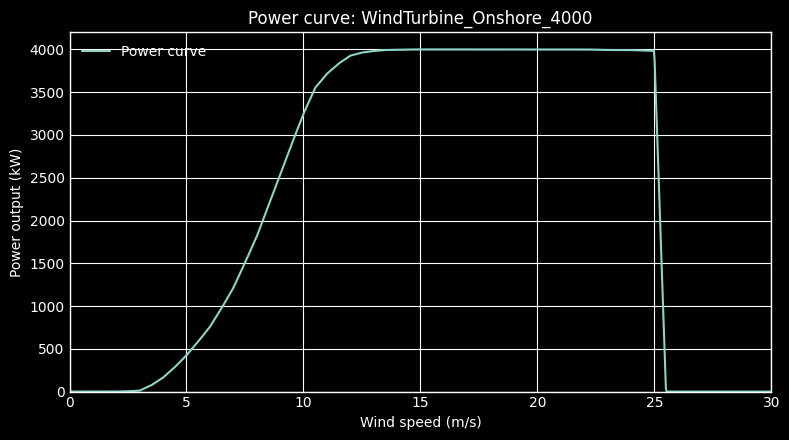

In [47]:
# Vizualize power curve

x_plot = np.linspace(0, 30, 1000)
y_plot = f(x_plot).ravel()

plt.figure(figsize=(8, 4.5))
plt.plot(x_plot, y_plot, label="Power curve")
plt.xlabel("Wind speed (m/s)")
plt.ylabel("Power output (kW)")
plt.title(f"Power curve: {name}")
plt.legend()
plt.grid(True)
plt.xlim(0, 30)
plt.ylim(0, max(float(rated_capacity) * 1.05, power_output.max() * 1.05))
plt.tight_layout()
plt.show()

In [48]:
# Weather data - DO NOT CHANGE
df = climate_data['dataframe']

if "ws100" in df.columns:
    ws = df["ws100"]
    ws_height = 100
else:
    ws = df["ws10"]
    ws_height = 10

alpha = 1/7

if hubheight > 0:
    ws = ws * (hubheight / ws_height) ** alpha

In [49]:
# defining pv data - DO NOT CHANGE

pv_system_data = dict()
pv_system_data["tilt"] = 18
pv_system_data["surface_azimuth"] = 180
pv_system_data["module_name"] = "SunPower_SPR_X20_327"
pv_system_data["inverter_eff"] = 0.96

inverter_parameters = {
    "pdc0": 5000,
    "eta_inv_nom": pv_system_data["inverter_eff"],
}

In [50]:
# Fitting pv system - DO NOT CHANGE
module_database = pvlib.pvsystem.retrieve_sam("CECMod")
module = module_database[pv_system_data["module_name"]]

temperature_model_parameters = (
    pvlib.temperature.TEMPERATURE_MODEL_PARAMETERS["sapm"][
        "open_rack_glass_glass"
    ]
)

# Create PV model chain
inverter_parameters = {
    "pdc0": 5000,
    "eta_inv_nom": pv_system_data["inverter_eff"],
}

system = pvlib.pvsystem.PVSystem(
    surface_tilt=pv_system_data["tilt"],
    surface_azimuth=pv_system_data["surface_azimuth"],
    module_parameters=module,
    inverter_parameters=inverter_parameters,
    temperature_model_parameters=temperature_model_parameters,
)

# Get location
tz = 'Europe/Amsterdam'

location = pvlib.location.Location(node_lat, node_lon, tz=tz, altitude=node_alt)

pv_model = pvlib.modelchain.ModelChain(
    system, location, spectral_model="no_loss", aoi_model="physical"
)
peakpower = module.STC

In [51]:
# Electricity and Heat demand data
import calendar

skip = sum(calendar.monthrange(year, m)[1] for m in range(1, month)) * 24

demand_data_path = 'data/demand_production.xlsx'
df_p1 = pd.read_excel(demand_data_path, sheet_name='Point1', header=1)

el_demand   = df_p1['Electricity [MWh]'].iloc[skip : skip + len(times)].reset_index(drop=True)
el_demand = el_demand * electricity_demand_multiplier

heat_demand = df_p1['Heat [MWh]'].iloc[skip : skip + len(times)].reset_index(drop=True)
heat_demand = heat_demand * heat_demand_multiplier

# print(f"Total electricity demand: {el_demand.sum():.1f} MWh")
# print(f"Average hourly demand: {el_demand.mean():.1f} MW")
# print(f"Peak demand: {el_demand.max():.1f} MW")
# print(f"Hours in dataset: {len(el_demand)}")  # should be 672 for February 2009

In [52]:
# Energy production

# Hours to skip to reach the selected month
skip_hours = sum(calendar.monthrange(year, m)[1] for m in range(1, month)) * 24

# wind capacity factor
capacity_factor_wind = f(np.clip(ws.values, 0, 35)) / 4000
capacity_factor_wind = pd.Series(
    np.asarray(capacity_factor_wind).flatten()[skip_hours:skip_hours + len(times)],
    index=times
)

# solar capacity factor
pv_model.run_model(df)
power = pv_model.results.ac.p_mp
capacity_factor_solar = power / peakpower

capacity_factor_solar = pd.Series(
    np.asarray(capacity_factor_solar).flatten()[skip_hours:skip_hours + len(times)],
    index=times
)

/home/krivero/anaconda3/envs/esi_final/lib/python3.13/site-packages/scipy/optimize/_chandrupatla.py:437: RuntimeWarning: invalid value encountered in divide
  C = A / (A + B)


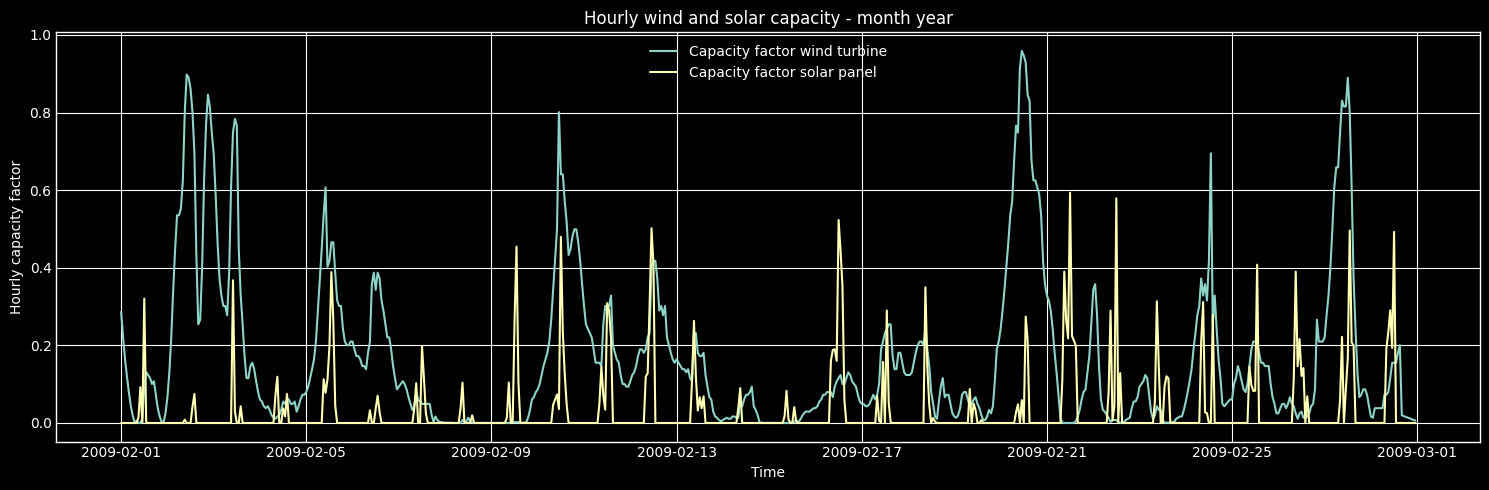

In [53]:
# Plot of capacity factors

plt.figure(figsize=(15, 5))

plt.plot(capacity_factor_wind.index, capacity_factor_wind, label='Capacity factor wind turbine')
plt.plot(capacity_factor_solar.index, capacity_factor_solar, label='Capacity factor solar panel')

plt.xlabel('Time')
plt.ylabel('Hourly capacity factor')
plt.title('Hourly wind and solar capacity - month year')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [54]:
# Obtaining techno-economic data

tech_eco_data_path = 'data/technoeconomic_data.xlsx'
tech_eco_data = pd.read_excel(tech_eco_data_path, sheet_name='Data', header=2)

def get_value(df, component, data_type):
    mask = (df['component'] == component) & (df['parameter'] == data_type)
    result = df.loc[mask, 'value']
    if len(result) == 0:
        raise ValueError(f"No data found for component='{component}', parameter='{data_type}'")
    return result.values[0]

# We give you the wind turbine techno-economic data import as example. Save all the relevant data with the same function
# !!Make sure to use the correct units!!

# Wind turbine
Wind_capex = get_value(tech_eco_data, 'Wind turbine', 'Investment cost')  # EUR/kW
Wind_lifetime = get_value(tech_eco_data, 'Wind turbine', 'Lifetime')  # year
Wind_opex = get_value(tech_eco_data, 'Wind turbine', 'Opex') / 100  # % capex/year

## Start of our model code
### Bring in additional techno-economic data

In [55]:
# grab additional techno-economic data
Solar_capex = get_value(tech_eco_data, 'Solar panel', 'Investment cost')  #EUR/kw
Solar_lifetime = get_value(tech_eco_data, 'Solar panel', 'Lifetime') # year
Solar_opex = get_value(tech_eco_data, 'Solar panel', 'Opex') / 100 # % capex/year math included
Electricity_cable_capex = get_value(tech_eco_data, 'Electricity cable', 'Investment cost') #EUR/kw/km
Electricity_cable_lifetime = get_value(tech_eco_data, 'Electricity cable', 'Lifetime') # year
Electricity_cable_fixed_opex = get_value(tech_eco_data, 'Electricity cable', 'Fixed Opex') / 100 # %capex/year
Electricity_cable_losses = get_value(tech_eco_data, 'Electricity cable', 'Losses') / 100 # % per 100km

# relevant for part 2
# Hydrogen_pipeline_capex = get_value(tech_eco_data, 'Hydrogen pipeline', 'Investment cost') # Eur/kw/km
# Hydrogen_pipeline_lifetime = get_value(tech_eco_data, 'Hydrogen pipeline', 'Lifetime') # year
# Hydrogen_pipeline_fixed_opex = get_value(tech_eco_data, 'Hydrogen pipeline', 'Fixed Opex') /100 # % capex/year
# Hydrogen_pipeline_losses = get_value(tech_eco_data, 'Hydrogen pipeline', 'Losses') /100 # % per 100km

Li_ion_battery_capex = get_value(tech_eco_data, 'Li-ion battery', 'Investment cost') # EUR/kWh
Li_ion_battery_lifetime = get_value(tech_eco_data, 'Li-ion battery', 'Lifetime') # year
Li_ion_battery_opex = get_value(tech_eco_data, 'Li-ion battery', 'Opex') / 100 # % capex/year
Li_ion_battery_charging_efficiency = get_value(tech_eco_data, 'Li-ion battery', 'Charging efficiency') / 100 # % input energy
Li_ion_battery_discharging_efficiency = get_value(tech_eco_data, 'Li-ion battery', 'Discharging efficiency') / 100 # % output energy
Li_ion_battery_self_discharge_coefficient = get_value(tech_eco_data, 'Li-ion battery', 'Self-discharge coefficient') / 100 # % per hour
Li_ion_battery_max_charging_capacity = get_value(tech_eco_data, 'Li-ion battery', 'Max charging capacity') / 100 # % size of battery
Li_ion_battery_max_discharging_capacity = get_value(tech_eco_data, 'Li-ion battery', 'Max discharging capacity') / 100 # % size of battery

# relevant for part 2
# Hydrogen_storage_tank_capex = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Investment cost') # EUR/kWh
# Hydrogen_storage_tank_lifetime = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Lifetime') #year
# Hydrogen_storage_tank_opex = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Opex') / 100 # % capex/year
# Hydrogen_storage_tank_charging_efficiency = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Charging efficiency') / 100 # % input energy
# Hydrogen_storage_tank_discharging_efficiency = get_value(tech_eco_data, 'Hydrogen storage - tank','Discharging efficiency') # error in data this does not need division by 100 % output energy
# Hydrogen_storage_tank_self_discharge_coefficient = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Self-discharge coefficient') / 100# %/hour
# Hydrogen_storage_tank_max_charging_capacity = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Max charging capacity') / 100 # %/size
# Hydrogen_storage_tank_max_discharging_capacity = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Max discharging capacity') / 100 # %/size
# Hydrogen_storage_tank_max_capacity = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Max capacity') # MW
#
# Heat_storage_high_temp_capex = get_value(tech_eco_data, 'Heat storage - High temp', 'Investment cost') # EUR/MWh
# Heat_storage_high_temp_lifetime = get_value(tech_eco_data, 'Heat storage - High temp', 'Lifetime') # year
# Heat_storage_high_temp_opex = get_value(tech_eco_data, 'Heat storage - High temp', 'Opex') / 100 # % capex/year
# Heat_storage_high_temp_charging_efficiency = get_value(tech_eco_data, 'Heat storage - High temp', 'Charging efficiency') / 100 # % input energy
# Heat_storage_high_temp_discharging_efficiency = get_value(tech_eco_data, 'Heat storage - High temp','Discharging efficiency') / 100 # % output energy
# Heat_storage_high_temp_self_discharge_coefficient = get_value(tech_eco_data, 'Heat storage - High temp', 'Self-discharge coefficient') # % / hour
# Heat_storage_high_temp_max_charging_capacity = get_value(tech_eco_data, 'Heat storage - High temp', 'Max charging capacity') / 100 # % size
# Heat_storage_high_temp_max_discharging_capacity = get_value(tech_eco_data, 'Heat storage - High temp', 'Max discharging capacity') / 100 # % size
#
# Heat_storage_low_temp_capex = get_value(tech_eco_data, 'Heat storage - Low temp', 'Investment cost') # EUR/MWh
# Heat_storage_low_temp_lifetime = get_value(tech_eco_data, 'Heat storage - Low temp', 'Lifetime') # year
# Heat_storage_low_temp_opex = get_value(tech_eco_data, 'Heat storage - Low temp', 'Opex') /100 # % capex/year
# Heat_storage_low_temp_charging_efficiency = get_value(tech_eco_data, 'Heat storage - Low temp', 'Charging efficiency') / 100 # % input energy
# Heat_storage_low_temp_discharging_efficiency = get_value(tech_eco_data, 'Heat storage - Low temp','Discharging efficiency') / 100# % output energy
# Heat_storage_low_temp_self_discharge_coefficient = get_value(tech_eco_data, 'Heat storage - Low temp', 'Self-discharge coefficient') / 100 # % / hour
# Heat_storage_low_temp_max_charging_capacity = get_value(tech_eco_data, 'Heat storage - Low temp', 'Max charging capacity') / 100 # % size
# Heat_storage_low_temp_max_discharging_capacity = get_value(tech_eco_data, 'Heat storage - Low temp', 'Max discharging capacity') / 100 # % size
#
# Heat_pump_coefficient_of_performance = get_value(tech_eco_data, 'Heat pump', 'COP') # no unit
# Hydrogen_boiler_efficiency = get_value(tech_eco_data, 'Hydrogen boiler', 'Efficiency') / 100 # % input energy
Operational_cost_lost_load_penalty = get_value(tech_eco_data, 'Operational cost', 'Lost load penalty') # EUR/MWh
Operational_cost_max_import_availability = get_value(tech_eco_data, 'Operational cost', 'Max import availability') # MWh
Operational_cost_electricity_import_cost = get_value(tech_eco_data, 'Operational cost', 'Electricity import cost') # EUR/MWh
# Operational_cost_hydrogen_market_price = get_value(tech_eco_data, 'Operational cost', 'Hydrogen market price') # EUR/MWh


## PyPSA Model for Scenario C
The code below is shared as an exemple of the PyPSA model structure used for analysis of the Part 1 design. Different scenarios were made with different choices in the model parameters to encourage different results in the KPIs of system cost, RES curtailment, utilization factor of the line, and unserved demand. Continue to the ***Comparison Section*** for comparison across scenarios.

In [56]:
# PYPSA Following 1 Node Example
# https://docs.pypsa.org/latest/examples/capacity-expansion-planning-single-node/#model-initialisation
import pandas as pd
import pypsa
from pypsa.costs import annuity
import cartopy.crs as ccrs
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

# data prep and variables
r = 0.05

# Battery parameters
p_nom_guess = 10  # MW, initial guess
# battery_energy_capacity = 25  # MWh, from your Li-ion spec
# battery_max_hours = battery_energy_capacity / p_nom_guess
eta_charge = Li_ion_battery_charging_efficiency # eta is efficiency
eta_discharge = Li_ion_battery_discharging_efficiency
max_charge_pu = Li_ion_battery_max_charging_capacity

# annualize the CAPEX
annualized_capex_wind = (Wind_capex*1000) * annuity(r, Wind_lifetime)
annualized_capex_solar = (Solar_capex*1000) * annuity(r, Solar_lifetime)
# annualized_capex_wind_manual = 80600 # eur/MW/y
# annualized_capex_solar_manual = 34200 # eur/MW/y
max_hours_bat = 4 #
annualized_capex_battery = (Li_ion_battery_capex*1000) * max_hours_bat * annuity(r, Li_ion_battery_lifetime) #eur/Mwh * h * annuity = eur/MW
annualized_capex_transmission = (Electricity_cable_capex*1000) * distance12 * annuity(r, Electricity_cable_lifetime) # Eur/kw/km * 1000 * km

#annualize the OPEX
annualized_opex_wind = (Wind_capex * 1000) * Wind_opex  # overnight capex * % = €/MW/year
annualized_opex_solar = (Solar_capex * 1000) * Solar_opex
annualized_opex_battery = (Li_ion_battery_capex * 1000) * Li_ion_battery_opex
annualized_opex_transmission = (Electricity_cable_capex* 1000) * distance12 * Electricity_cable_fixed_opex

capital_cost_solar = annualized_capex_solar + annualized_opex_solar
capital_cost_wind = annualized_capex_wind + annualized_opex_wind
capital_cost_battery = (annualized_capex_battery + annualized_opex_battery) #confusion around whether multiplying by max hours is needed but I think correct
capital_cost_transmission = annualized_capex_transmission + annualized_opex_transmission

# old approach for demand df keep just in case
# conversions timestamp based index vs. integer, repulling from df_p1 so need to re-multiply
el_demand = df_p1['Electricity [MWh]'].iloc[skip : skip + len(times)]
el_demand = el_demand.set_axis(times)
el_demand = el_demand * electricity_demand_multiplier
el_demand.index = pd.to_datetime(el_demand.index).tz_localize(None)
capacity_factor_wind.index = pd.to_datetime(capacity_factor_wind.index).tz_localize(None)
capacity_factor_solar.index = pd.to_datetime(capacity_factor_solar.index).tz_localize(None)

ts = pd.concat(
    [
        el_demand.rename("e_load_mw"),
        capacity_factor_wind.rename("wind_pu"),
        capacity_factor_solar.rename("solar_pu"),
    ],
    axis=1
)

# sanity check
assert len(ts) == len(times), f"Time series length mismatch: {len(ts)} vs {len(times)}"

#network setup
RESOLUTION = 1 # hourly
n = pypsa.Network()

REGIONS_ELEC = ["zone1", "zone2"]
LAT = [node_lat, 54.279]
LON = [node_lon, 10.164]
# ready for later:
# REGIONS_H2   = ["zone1", "zone3"]
# REGIONS_HEAT = ["zone2"]

ZONES = {
    "zone1": {"carrier": "electricity", "has_generation": True,  "has_load": False},
    "zone2": {"carrier": "electricity", "has_generation": False, "has_load": True},
}

for zone, props in ZONES.items():
    n.add("Bus", zone, carrier=props["carrier"])

ts.index = ts.index.tz_localize(None)
n.set_snapshots(ts.index)
n.snapshot_weightings.loc[:, :] = RESOLUTION

carriers = [
    "demand",
    "wind",
    "solar",
    "battery storage",
    "load shedding",
    "electricity",
    "import",
]
colors = [
    "grey",
    "dodgerblue",
    "gold",
    "darkorange",
    "red",
    "white",
    "lightgreen",
]
n.add("Carrier", carriers, color=colors)

efficiency_transmission = (1 - Electricity_cable_losses) ** (distance12 / 100)  # = 0.9737 for 53km

n.add(
    "Link",
    "zone1-zone2",
    bus0="zone1",
    bus1="zone2",
    capital_cost=capital_cost_transmission,
    # p_min_pu=-1,         # bidirectional would be 1
    efficiency=efficiency_transmission,     # line losses 5% over 100km is what for 53km line
    p_nom_extendable=True,  # set True to co-optimize transmission
    p_nom_min=30,
    p_nom_mod=10 # MW — set to your known transfer capacity
    # p_nom=30
    # p_nom_extendable=False
)

# n.add(
#     "Link",
#     "zone1-zone2",
#     bus0="zone1",
#     bus1="zone2",
#     efficiency=efficiency_transmission,
#     p_nom_extendable=True,   # allow optimization to build more
#     p_nom_min=10,            # existing capacity
#     p_nom_mod=10,            # builds in steps of 10 MW
#     capital_cost=capital_cost_transmission,  # €/MW/year
# )

n.add(
    "Load",
    "demand",
    bus="zone2",
    carrier="demand",
    p_set=ts.e_load_mw,
)

n.add(
    "Generator",
    "load shedding",
    bus="zone2",
    carrier="load shedding",
    marginal_cost=Operational_cost_lost_load_penalty,
    p_nom=ts.e_load_mw.max(),
    # p_max_pu=0.05,  # at any hour, max shedding = 5% of p_nom
)

marginal_cost_wind = 0 # gave 0 here. assumed included in opex
marginal_cost_solar = 0

n.add(
    "Generator",
    "wind",
    bus="zone1",
    carrier="wind",
    p_max_pu=ts.wind_pu,
    capital_cost=capital_cost_wind, # using MW
    marginal_cost=marginal_cost_wind,
    p_nom_extendable=True, #note allows PyPSA optimization to choose how much capacity to build
    p_nom_min =50,
)

n.add(
    "Generator",
    "solar",
    bus="zone1",
    carrier="solar",
    p_max_pu=ts.solar_pu,
    capital_cost=capital_cost_solar, # using MW
    marginal_cost=marginal_cost_solar,
    p_nom_extendable=True, #note allows PyPSA optimization to choose how much capacity to build
    p_nom_min =50,
)

n.add(
    "Generator",
    "import",
    bus="zone2",
    carrier="import",
    marginal_cost=Operational_cost_electricity_import_cost,        # existing variable, €/MWh
    p_nom=Operational_cost_max_import_availability,    # existing variable, MW
    p_nom_extendable=False, # can't expand capacity any more than max
)

#manually swap batteries
n.add(
    "StorageUnit",
    "battery storage zone 1", #better way than manual swap to make sure only one battery built at a time?
    bus="zone1",
    carrier="battery storage",
    p_nom=p_nom_guess, #MW
    p_nom_extendable=True,
    max_hours=max_hours_bat, # E_max = p_nom * max_hours battery can go 3 hours at full discharge
    capital_cost=capital_cost_battery,
    efficiency_store=eta_charge,
    efficiency_dispatch=eta_discharge,
    standing_loss=Li_ion_battery_self_discharge_coefficient,
    p_max_pu=max_charge_pu,    # max discharge capacity = 50% of p_nom
    p_min_pu=-max_charge_pu,   # max charge capacity = 50% of p_nom (note: negative = charging)
    cyclic_state_of_charge=True, #The battery’s state of charge at the end of the simulation equals its starting state. Ensures no net energy accumulation over the optimization horizon. Important for representing a full year or cyclic operation
    state_of_charge_initial=0.5 * p_nom_guess * max_hours_bat,
)

# n.add(
#     "StorageUnit",
#     "battery storage zone 2", #manually swap in
#     bus="zone2",
#     carrier="battery storage",
#     p_nom=p_nom_guess, #MW
#     # max_hours=e_nom/p_nom, # E_max = p_nom * max_hours battery can go 3 hours at full discharge
#     capital_cost=capital_cost_battery,
#     efficiency_store=eta_charge,
#     efficiency_dispatch=eta_discharge,
#     standing_loss=0.00004,
#     p_max_pu=max_charge_pu,    # max discharge capacity = 50% of p_nom
#     p_min_pu=-max_charge_pu,   # max charge capacity = 50% of p_nom (note: negative = charging)
#     e_nom_extendable=True, # allowing capacity to increase in MWh
#     cyclic_state_of_charge=True, #The battery’s state of charge at the end of the simulation equals its starting state. Ensures no net energy accumulation over the optimization horizon. Important for representing a full year or cyclic operation
# )

# plotting aids
for zone, lat, lon in zip(REGIONS_ELEC, LAT, LON):
    n.buses.loc[zone, "y"] = lat
    n.buses.loc[zone, "x"] = lon

n.optimize()

#sanity checks
# print(annualized_capex_wind)  # ~80,600 €/MW/year
# print(annualized_capex_solar) # ~34,200 €/MW/year
# print(ts.solar_pu.describe())
# print(ts.e_load_mw.describe())

print(n.generators.p_nom_opt)          # optimized capacity by generator
print(n.storage_units.p_nom_opt)       # optimized battery capacity

/tmp/ipykernel_67889/1350469405.py:231: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize()
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.13s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 5382 primals, 12773 duals
Objective: 7.84e+06
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUni

Running HiGHS 1.13.1 (git hash: 1d267d9): Copyright (c) 2026 under MIT licence terms
MIP linopy-problem-ulm31v_2 has 12773 rows; 5382 cols; 22295 nonzeros; 1 integer variables (0 binary)
Coefficient ranges:
  Matrix  [1e-04, 1e+01]
  Cost    [1e+00, 1e+05]
  Bound   [1e+06, 1e+06]
  RHS     [1e+01, 5e+01]
Presolving model
5489 rows, 4820 cols, 13779 nonzeros  0s
4235 rows, 3681 cols, 11386 nonzeros  0s
4212 rows, 3658 cols, 11416 nonzeros  0s
Presolve reductions: rows 4212(-8561); columns 3658(-1724); nonzeros 11416(-10879) 

Solving MIP model with:
   4212 rows
   3658 cols (0 binary, 0 integer, 0 implied int., 3658 continuous, 0 domain fixed)
   11416 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Triv

In [57]:
# total cost by technology in Meuro
tsc = (
    pd.concat([n.statistics.capex(), n.statistics.opex()], axis=1).sum(axis=1) #.div(1e9)
)
tsc

component  carrier      
Generator  solar            2.270008e+06
           wind             5.209220e+06
Link       electricity      5.971794e+05
Generator  import           1.099590e+06
           load shedding    2.926645e+04
dtype: float64

In [58]:
tsc.sum()

np.float64(9205263.56237)

In [59]:
# optimized capacities in MW
n.statistics.optimal_capacity()

component  carrier      
Generator  import           25.0000
           load shedding    28.7827
           solar            50.0000
           wind             50.0000
Link       electricity      30.0000
dtype: float64

In [60]:
# Energy balances on electricity side (in MWh):
n.statistics.energy_balance(bus_carrier="electricity").sort_values()

component  carrier        bus_carrier
Load       demand         electricity   -12871.89984
Link       electricity    electricity     -152.17130
Generator  load shedding  electricity       19.51096
           solar          electricity      855.57710
           wind           electricity     4818.38164
           import         electricity     7330.60144
dtype: float64

#### Energy Balance - Scenario C

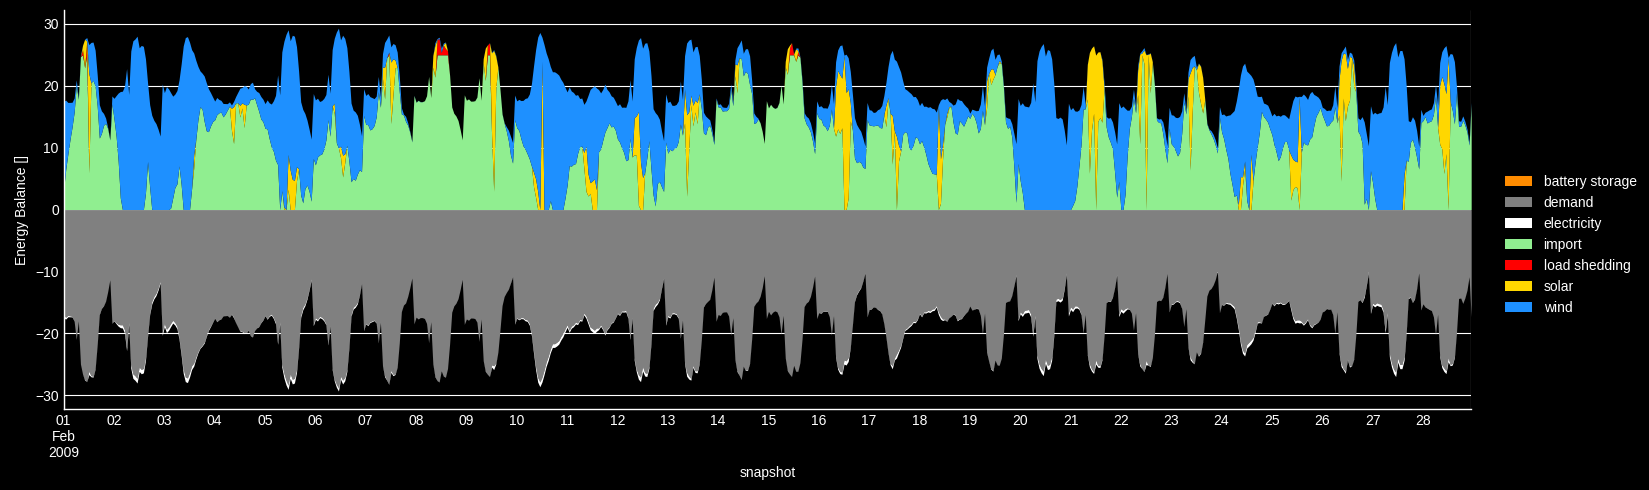

In [61]:
# Energy balances plot as time series (in MW):
sum(ts.e_load_mw)
n.statistics.energy_balance.plot.area(linewidth=0, bus_carrier="electricity",figsize=(15,5))
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")

<Axes: xlabel='snapshot'>

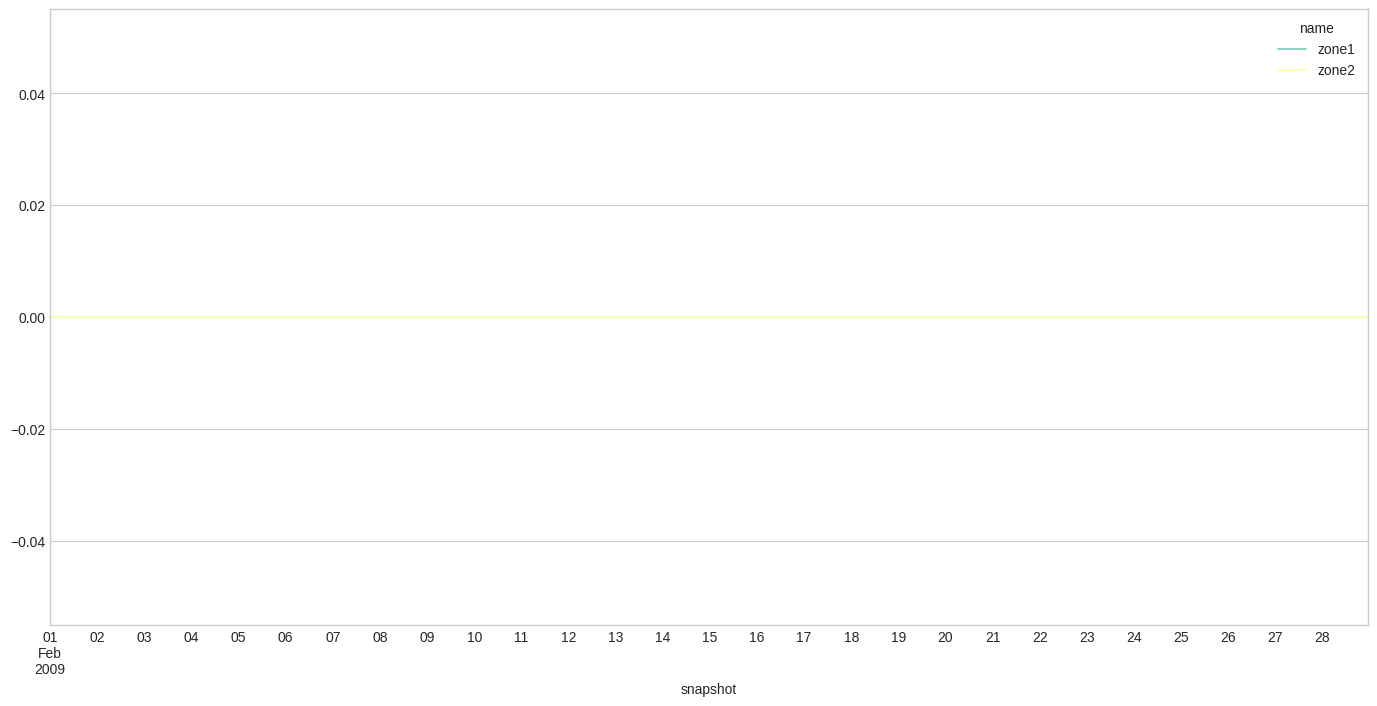

In [62]:
# Price time series for electricity:
n.buses_t.marginal_price.plot(figsize=(17, 8))

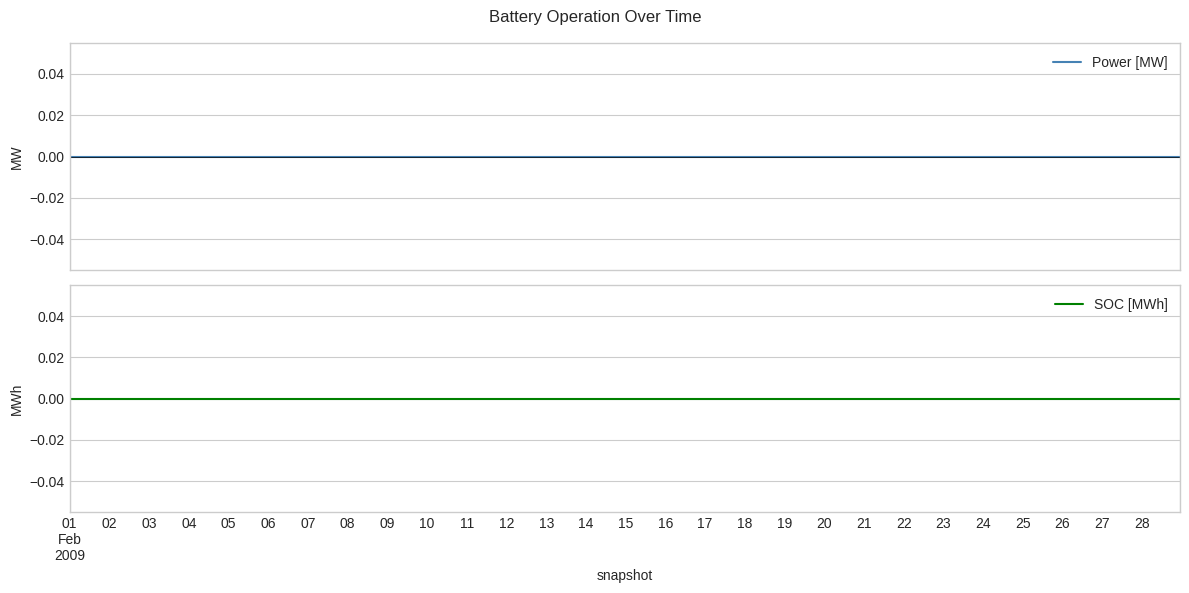

In [63]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Charge / discharge power
# n.storage_units_t.p["battery storage zone 2"].plot(
n.storage_units_t.p["battery storage zone 1"].plot(
    ax=axes[0], label="Power [MW]", color="steelblue"
)
axes[0].set_ylabel("MW")
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].legend()
axes[0].grid(True)

# Zone 2 SOC
# n.storage_units_t.state_of_charge["battery storage zone 2"].plot(
n.storage_units_t.state_of_charge["battery storage zone 1"].plot(
    ax=axes[1], label="SOC [MWh]", color="green"
)
axes[1].set_ylabel("MWh")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Battery Operation Over Time")
plt.tight_layout()
plt.show()

#### System Costs - Scenario C

Total system cost: €8.608M/year
Total system cost: €717340.35/month


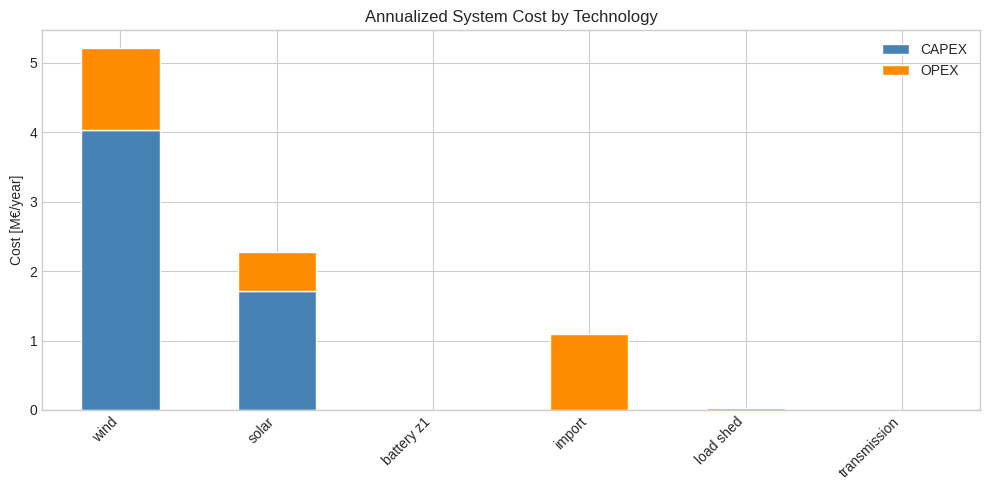

In [64]:
# Costs Reconstruction
# Reconstruct costs manually
opt_wind_mw = n.generators.p_nom_opt["wind"]
opt_solar_mw = n.generators.p_nom_opt["solar"]
opt_battery_z1_mw = n.storage_units.p_nom_opt["battery storage zone 1"]
# opt_battery_z2_mw = n.storage_units.p_nom_opt["battery storage zone 2"]
opt_import_mwh = n.generators_t.p["import"].sum()
opt_loadshed_mwh = n.generators_t.p["load shedding"].sum()

cost_data = {
    "wind":       {"CAPEX": annualized_capex_wind * opt_wind_mw,
                   "OPEX":  annualized_opex_wind  * opt_wind_mw},
    "solar":      {"CAPEX": annualized_capex_solar * opt_solar_mw,
                   "OPEX":  annualized_opex_solar  * opt_solar_mw},
    "battery z1": {"CAPEX": annualized_capex_battery * opt_battery_z1_mw,
                   "OPEX":  annualized_opex_battery  * opt_battery_z1_mw},
    # "battery z2": {"CAPEX": annualized_capex_battery * opt_battery_z2_mw,
    #                "OPEX":  annualized_opex_battery  * opt_battery_z2_mw},
    "import":     {"CAPEX": 0,
                   "OPEX":  Operational_cost_electricity_import_cost * opt_import_mwh},
    "load shed":  {"CAPEX": 0,
                   "OPEX":  Operational_cost_lost_load_penalty * opt_loadshed_mwh},
    "transmission": {"CAPEX": annualized_capex_transmission * n.links.loc["zone1-zone2", "p_nom"],
                     "OPEX":  annualized_opex_transmission  * n.links.loc["zone1-zone2", "p_nom"]},
}

cost_df = pd.DataFrame(cost_data).T.div(1e6)  # convert to M€

# plot
print(f"Total system cost: €{cost_df['CAPEX'].sum() + cost_df['OPEX'].sum():.3f}M/year")
total_annual_cost = cost_df['CAPEX'].sum() + cost_df['OPEX'].sum()
total_monthly_cost = total_annual_cost * 1e6/ 12
print(f"Total system cost: €{total_monthly_cost:.2f}/month")
fig, ax = plt.subplots(figsize=(10, 5))
cost_df[["CAPEX", "OPEX"]].plot(kind="bar", stacked=True, ax=ax,
                                 color=["steelblue", "darkorange"])
ax.set_ylabel("Cost [M€/year]")
ax.set_title("Annualized System Cost by Technology")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#### Curtailment - Scenario C

Total curtailment: 1146.2 MWh
Wind curtailment: 859.7 MWh
Solar curtailment: 286.5 MWh


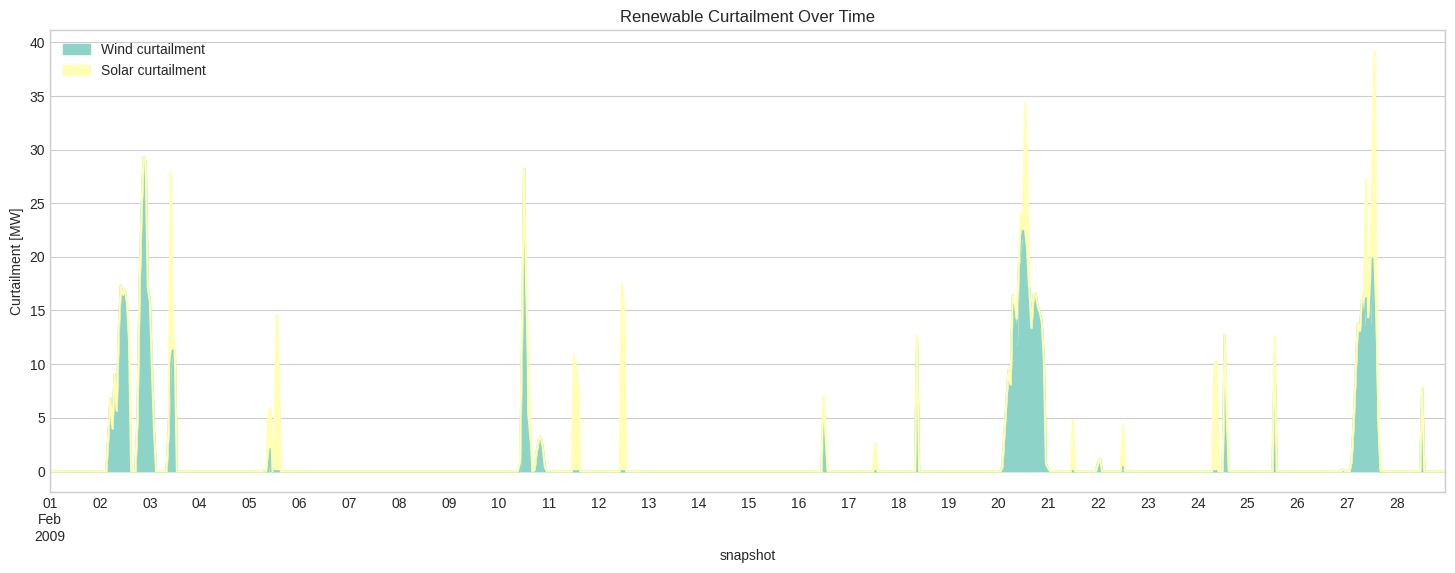

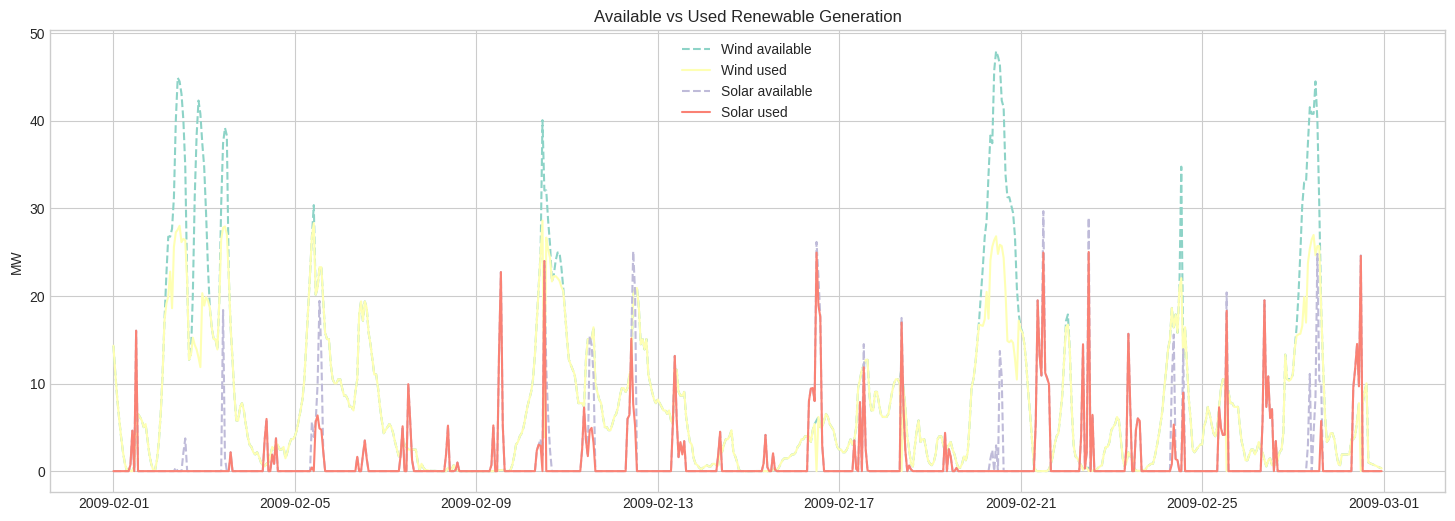

In [65]:
# Available generation (MW)
opt_wind_mw = n.generators.p_nom_opt["wind"] * n.generators_t.p_max_pu["wind"]
opt_solar_mw = n.generators.p_nom_opt["solar"] * n.generators_t.p_max_pu["solar"]

# Actual generation (MW)
gen_wind = n.generators_t.p["wind"]
gen_solar = n.generators_t.p["solar"]

# Curtailment (MW)
curtailment_wind = opt_wind_mw - gen_wind
curtailment_solar = opt_solar_mw - gen_solar

# Clean numerical noise
curtailment_wind = curtailment_wind.clip(lower=0)
curtailment_solar = curtailment_solar.clip(lower=0)

total_curtailment = (curtailment_wind + curtailment_solar).sum()

print(f"Total curtailment: {total_curtailment:.1f} MWh")
print(f"Wind curtailment: {curtailment_wind.sum():.1f} MWh")
print(f"Solar curtailment: {curtailment_solar.sum():.1f} MWh")

curtailment_df = pd.DataFrame({
    "Wind curtailment": curtailment_wind,
    "Solar curtailment": curtailment_solar
})

curtailment_df.plot.area(figsize=(18,6))
plt.ylabel("Curtailment [MW]")
plt.title("Renewable Curtailment Over Time")
plt.grid(True)
plt.show()

plt.figure(figsize=(18,6))

plt.plot(opt_wind_mw, label="Wind available", linestyle="--")
plt.plot(gen_wind, label="Wind used")

plt.plot(opt_solar_mw, label="Solar available", linestyle="--")
plt.plot(gen_solar, label="Solar used")

plt.legend()
plt.title("Available vs Used Renewable Generation")
plt.ylabel("MW")
plt.grid(True)
plt.show()

#### Transmission - Scenario C

30.0
Optimized capacity: 30.0 MW
Max flow used: 28.6 MW
30.0
Average utilization: 28.14%
Max utilization: 95.35%
Congested hours: 0


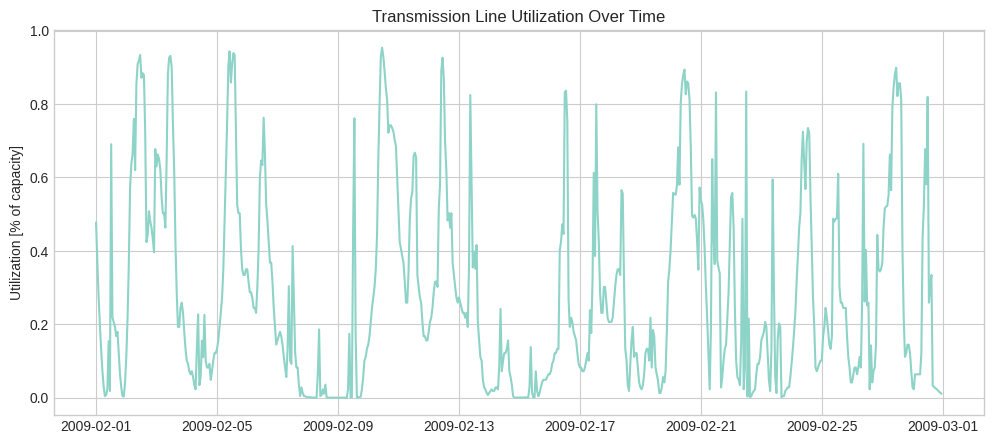

In [66]:
# post allowing transmission building
opt_line_capacity = n.links.p_nom_opt["zone1-zone2"]

#pre-freedom to build
opt_flow = n.links_t.p0["zone1-zone2"]
# opt_line_capacity = n.links.loc["zone1-zone2", "p_nom"]
utilization = opt_flow.abs() / opt_line_capacity
avg_util = utilization.mean()
max_util = utilization.max()
congested_hours = (utilization > 0.99).sum()

print(n.links.p_nom_opt["zone1-zone2"])
print(f"Optimized capacity: {opt_line_capacity} MW")
print(f"Max flow used: {opt_flow.abs().max():.1f} MW")

print(opt_line_capacity)
print(f"Average utilization: {avg_util:.2%}")
print(f"Max utilization: {max_util:.2%}")
print(f"Congested hours: {congested_hours}")

plt.figure(figsize=(12,5))
plt.plot(utilization)
plt.ylabel("Utilization [% of capacity]")
plt.title("Transmission Line Utilization Over Time")
plt.grid(True)
plt.show()

#### Unserved Demand - Scenario C

In [67]:
unserved_mwh = n.generators_t.p["load shedding"].sum()

print(f"Total unserved demand: {unserved_mwh:.1f} MWh")

Total unserved demand: 19.5 MWh


## Comparison Section
In the cells below we compare multiple scenarios across the following KPIs
- Total System Cost
- RES Curtailment
- Transmission Utilization
- Unserved Demand
- Energy Security

### What is our dataset like?
Our dataset corresponds to a location on the Jutland peninsula in Northern Germany in the month February. The demand is relatively low compared to the available wind and ample import capacity. While solar capacity factors are low, wind is producing enough power (although intermittently).

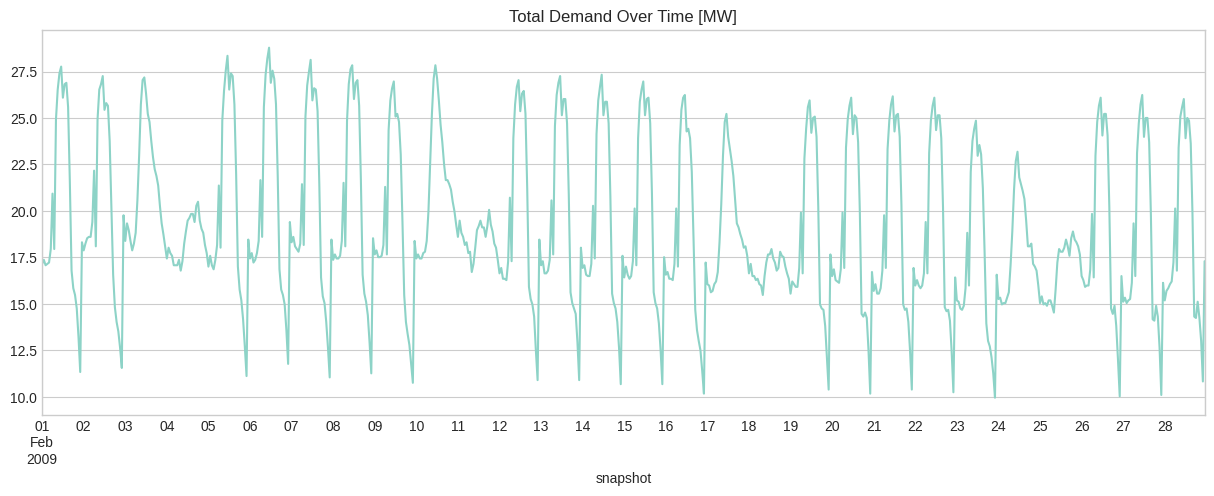

In [68]:
ax = n.loads_t.p_set.sum(axis=1).plot(figsize=(15,5), title="Total Demand Over Time [MW]")

In [69]:
n.loads_t.p_set.describe()

name,demand
count,672.000000
mean,19.154613
std,4.430892
min,9.957652
25%,16.063072
50%,17.989188
75%,23.222406
max,28.782701


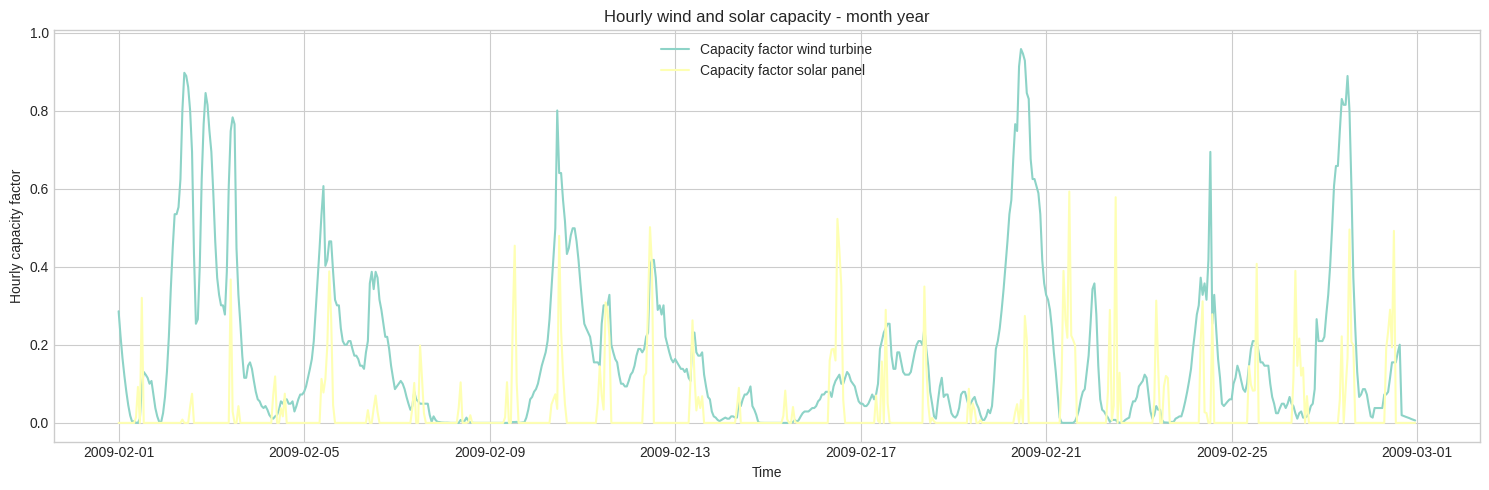

In [70]:
# Plot of capacity factors

plt.figure(figsize=(15, 5))

plt.plot(capacity_factor_wind.index, capacity_factor_wind, label='Capacity factor wind turbine')
plt.plot(capacity_factor_solar.index, capacity_factor_solar, label='Capacity factor solar panel')

plt.xlabel('Time')
plt.ylabel('Hourly capacity factor')
plt.title('Hourly wind and solar capacity - month year')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Scenario Goals
In our models we ran a number of scenarios to investigate the relationship between design parameters and numerous KPIs. The parameter configurations of each scenario can be found here:
https://docs.google.com/spreadsheets/d/1TDLvnTkoasLHzYvYxa_W-6mtMj7YGGRmXB0ouGcNCcE/edit?gid=0#gid=0

### KPI Overview

INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, links, loads, storage_units, sub_networks
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, links, loads, storage_units, sub_networks
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, links, loads, storage_units, sub_networks
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, links, loads, storage_units, sub_networks
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, links, loads, storage_units, sub_networks


                   Wind [MW]  Solar [MW]  Battery [MW]  Line [MW]  \
Full Optimization       -0.0         0.0           0.0        0.0   
Scenario A              50.0        50.0           0.0       30.0   
Scenario B              50.0        50.0           0.0       30.0   
Scenario C              50.0        50.0          10.0       30.0   
Scenario D              50.0        50.0           0.0       20.0   

                   Import [MWh]  Load shed [MWh]  Total cost [M€/y]  \
Full Optimization  12731.039759       140.860077           2.120946   
Scenario A          7330.601444        19.510964           8.608084   
Scenario B          7330.601444        19.510964           8.608084   
Scenario C          7077.840387         0.000000          10.499253   
Scenario D          7668.539297        19.510964           9.081346   

                   Wind curtailment [hours]  Solar curtailment [hours]  \
Full Optimization                  0.000000                   0.000000   
Scenario A

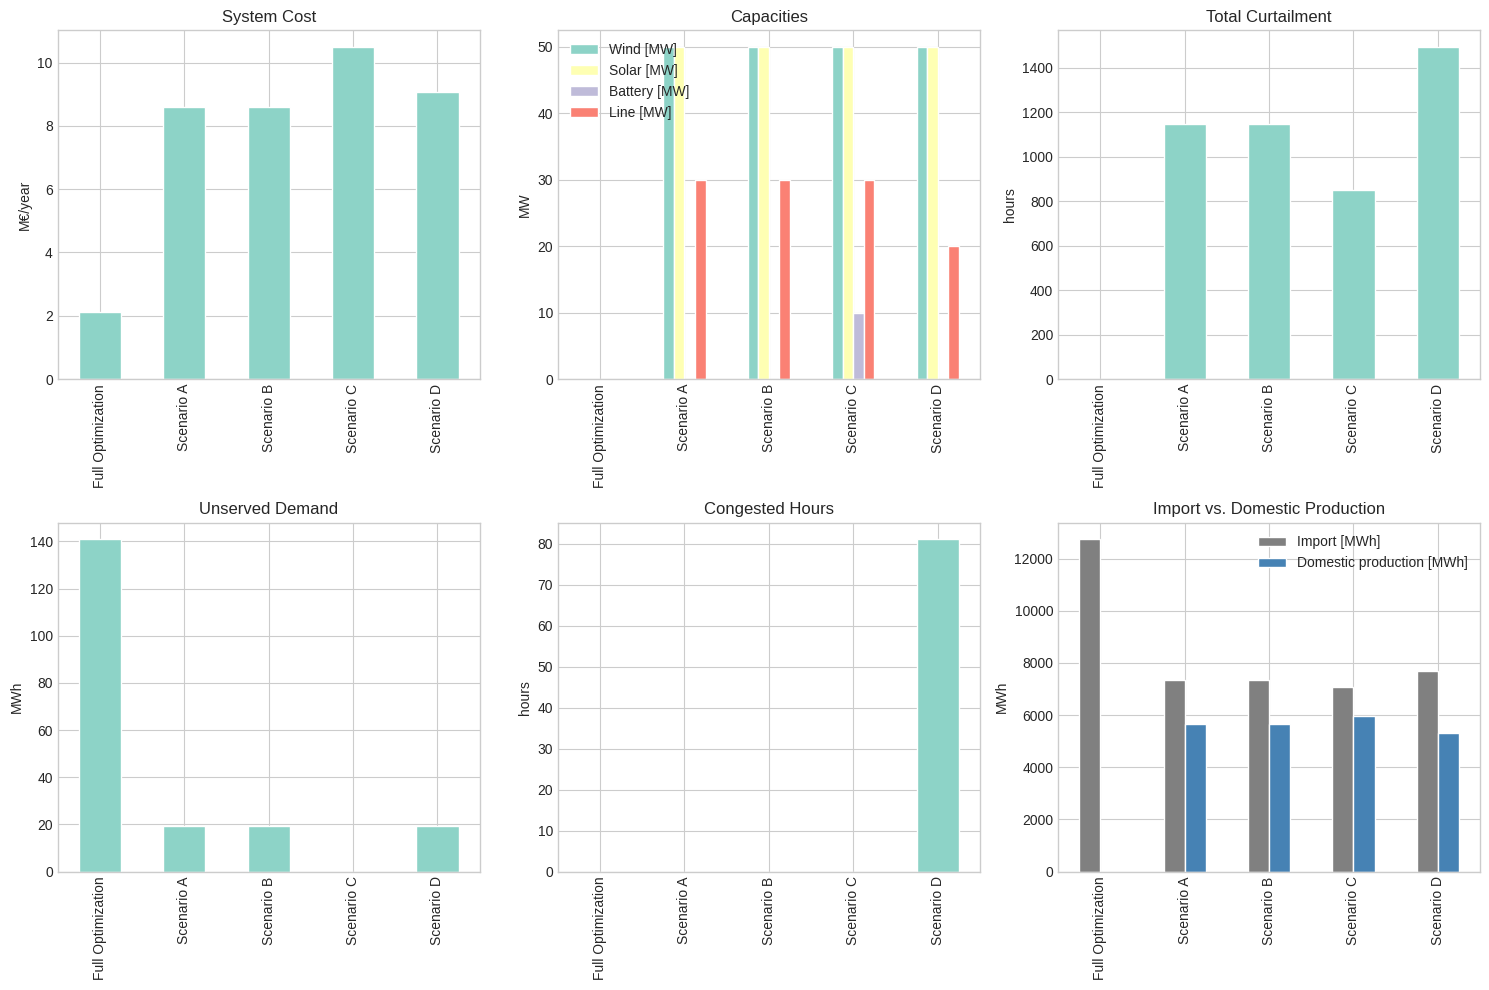

In [102]:
# Run / load each scenario
# PyPSA scenario runs were saved as netCDF
networks = {
    "Full Optimization": pypsa.Network("results/full_opt.nc"),
    "Scenario A": pypsa.Network("results/scenario_A.nc"),
    "Scenario B": pypsa.Network("results/scenario_B.nc"),
    "Scenario C": pypsa.Network("results/scenario_C.nc"),
    "Scenario D": pypsa.Network("results/scenario_D.nc"),
}

# Extract KPIs from each network
def extract_kpis(n, label):
    opt_wind     = n.generators.p_nom_opt.get("wind", 0)
    opt_solar    = n.generators.p_nom_opt.get("solar", 0)
    opt_batt     = n.storage_units.p_nom_opt.sum()
    opt_line     = n.links.p_nom_opt.get("zone1-zone2", n.links.p_nom.get("zone1-zone2", 0))

    import_mwh   = n.generators_t.p.get("import", pd.Series(0)).sum()
    loadshed_mwh = n.generators_t.p.get("load shedding", pd.Series(0)).sum()
    unserved_mwh = n.generators_t.p["load shedding"].sum()

    #curtailment
    opt_wind_mw = n.generators.p_nom_opt["wind"] * n.generators_t.p_max_pu["wind"] # MW times capacity factor
    opt_solar_mw = n.generators.p_nom_opt["solar"] * n.generators_t.p_max_pu["solar"]
    gen_wind = n.generators_t.p["wind"]
    gen_solar = n.generators_t.p["solar"]
    curtailment_wind = opt_wind_mw - gen_wind
    curtailment_solar = opt_solar_mw - gen_solar
    curtailment_wind = curtailment_wind.clip(lower=0).sum()
    curtailment_solar = curtailment_solar.clip(lower=0).sum()
    total_curtailment = (curtailment_wind + curtailment_solar).sum()

    # energy security
    domestic_production = (gen_wind + gen_solar).sum()

    #congestion
    if "zone1-zone2" in n.links_t.p0.columns:
        opt_line_capacity = n.links.p_nom_opt.get("zone1-zone2", n.links.p_nom.get("zone1-zone2", 0))
        if opt_line_capacity > 0:
            opt_flow = n.links_t.p0["zone1-zone2"]
            utilization = opt_flow.abs() / opt_line_capacity
            congested_hours = (utilization > 0.99).sum()
        else:
            congested_hours = 0
    else:
            congested_hours = 0
    # avg_util = utilization.mean()
    # max_util = utilization.max()

    total_cost = (
        pd.concat([n.statistics.capex(), n.statistics.opex()], axis=1)
        .sum(axis=1).sum() / 1e6          # M€/year
    )

    return {
        "Wind [MW]":        opt_wind,
        "Solar [MW]":       opt_solar,
        "Battery [MW]":     opt_batt,
        "Line [MW]":        opt_line,
        "Import [MWh]":     import_mwh,
        "Load shed [MWh]":  loadshed_mwh,
        "Total cost [M€/y]": total_cost,
        "Wind curtailment [hours]": curtailment_wind,
        "Solar curtailment [hours]": curtailment_solar,
        "Total curtailment [hours]": total_curtailment,
        "Total unserved [MWh]": unserved_mwh,
        "Congested hours": congested_hours,
        "Domestic production [MWh]": domestic_production,
    }

kpis = pd.DataFrame(
    {label: extract_kpis(n, label) for label, n in networks.items()}
)
print(kpis.T)

# ── 3. Side-by-side bar charts ────────────────────────────────────────────────
plt.style.use("seaborn-v0_8-whitegrid")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

kpis.loc[["Total cost [M€/y]"]].T \
    .plot(kind="bar", ax=axes[0], legend=False)
axes[0].set_title("System Cost"); axes[0].set_ylabel("M€/year")

kpis.loc[["Wind [MW]", "Solar [MW]", "Battery [MW]", "Line [MW]"]].T \
    .plot(kind="bar", ax=axes[1]); axes[1].set_title("Capacities"); axes[1].set_ylabel("MW")

kpis.loc[["Total curtailment [hours]"]].T \
    .plot(kind="bar", ax=axes[2], legend=False)
axes[2].set_title("Total Curtailment"); axes[2].set_ylabel("hours")

kpis.loc[["Total unserved [MWh]"]].T \
    .plot(kind="bar", ax=axes[3], legend=False)
axes[3].set_title("Unserved Demand"); axes[3].set_ylabel("MWh")

kpis.loc[["Congested hours"]].T \
    .plot(kind="bar", ax=axes[4], legend=False)
axes[4].set_title("Congested Hours"); axes[4].set_ylabel("hours")

kpis.loc[["Import [MWh]", "Domestic production [MWh]"]].T \
    .plot(kind="bar", ax=axes[5], color=["grey", "steelblue"]); axes[5].set_title("Import vs. Domestic Production"); axes[5].set_ylabel("MWh")

plt.tight_layout(); plt.show()

### System Cost Comparision

In [72]:
def build_cost_df(n, annualized_capex_wind, annualized_opex_wind,
                      annualized_capex_solar, annualized_opex_solar,
                      annualized_capex_battery, annualized_opex_battery,
                      annualized_capex_transmission, annualized_opex_transmission,
                      Operational_cost_electricity_import_cost,
                      Operational_cost_lost_load_penalty):

    opt_wind      = n.generators.p_nom_opt.get("wind", 0)
    opt_solar     = n.generators.p_nom_opt.get("solar", 0)
    opt_battery_z1 = n.storage_units.p_nom_opt.get("battery storage zone 1", 0)
    opt_import_mwh   = n.generators_t.p.get("import", pd.Series(dtype=float)).sum()
    opt_loadshed_mwh = n.generators_t.p.get("load shedding", pd.Series(dtype=float)).sum()

    cost_data = {
        "wind":         {"CAPEX": annualized_capex_wind  * opt_wind,
                         "OPEX":  annualized_opex_wind   * opt_wind},
        "solar":        {"CAPEX": annualized_capex_solar * opt_solar,
                         "OPEX":  annualized_opex_solar  * opt_solar},
        "battery z1":   {"CAPEX": annualized_capex_battery * opt_battery_z1,
                         "OPEX":  annualized_opex_battery  * opt_battery_z1},
        "import":       {"CAPEX": 0,
                         "OPEX":  Operational_cost_electricity_import_cost * opt_import_mwh},
        "load shed":    {"CAPEX": 0,
                         "OPEX":  Operational_cost_lost_load_penalty * opt_loadshed_mwh},
        "transmission": {"CAPEX": annualized_capex_transmission * n.links.loc["zone1-zone2", "p_nom"],
                         "OPEX":  annualized_opex_transmission  * n.links.loc["zone1-zone2", "p_nom"]},
    }

    return pd.DataFrame(cost_data).T.div(1e6)  # M€


# ── Cost parameters (shared across scenarios) ─────────────────────────────────
cost_params = dict(
    annualized_capex_wind=annualized_capex_wind,
    annualized_opex_wind=annualized_opex_wind,
    annualized_capex_solar=annualized_capex_solar,
    annualized_opex_solar=annualized_opex_solar,
    annualized_capex_battery=annualized_capex_battery,
    annualized_opex_battery=annualized_opex_battery,
    annualized_capex_transmission=annualized_capex_transmission,
    annualized_opex_transmission=annualized_opex_transmission,
    Operational_cost_electricity_import_cost=Operational_cost_electricity_import_cost,
    Operational_cost_lost_load_penalty=Operational_cost_lost_load_penalty,
)

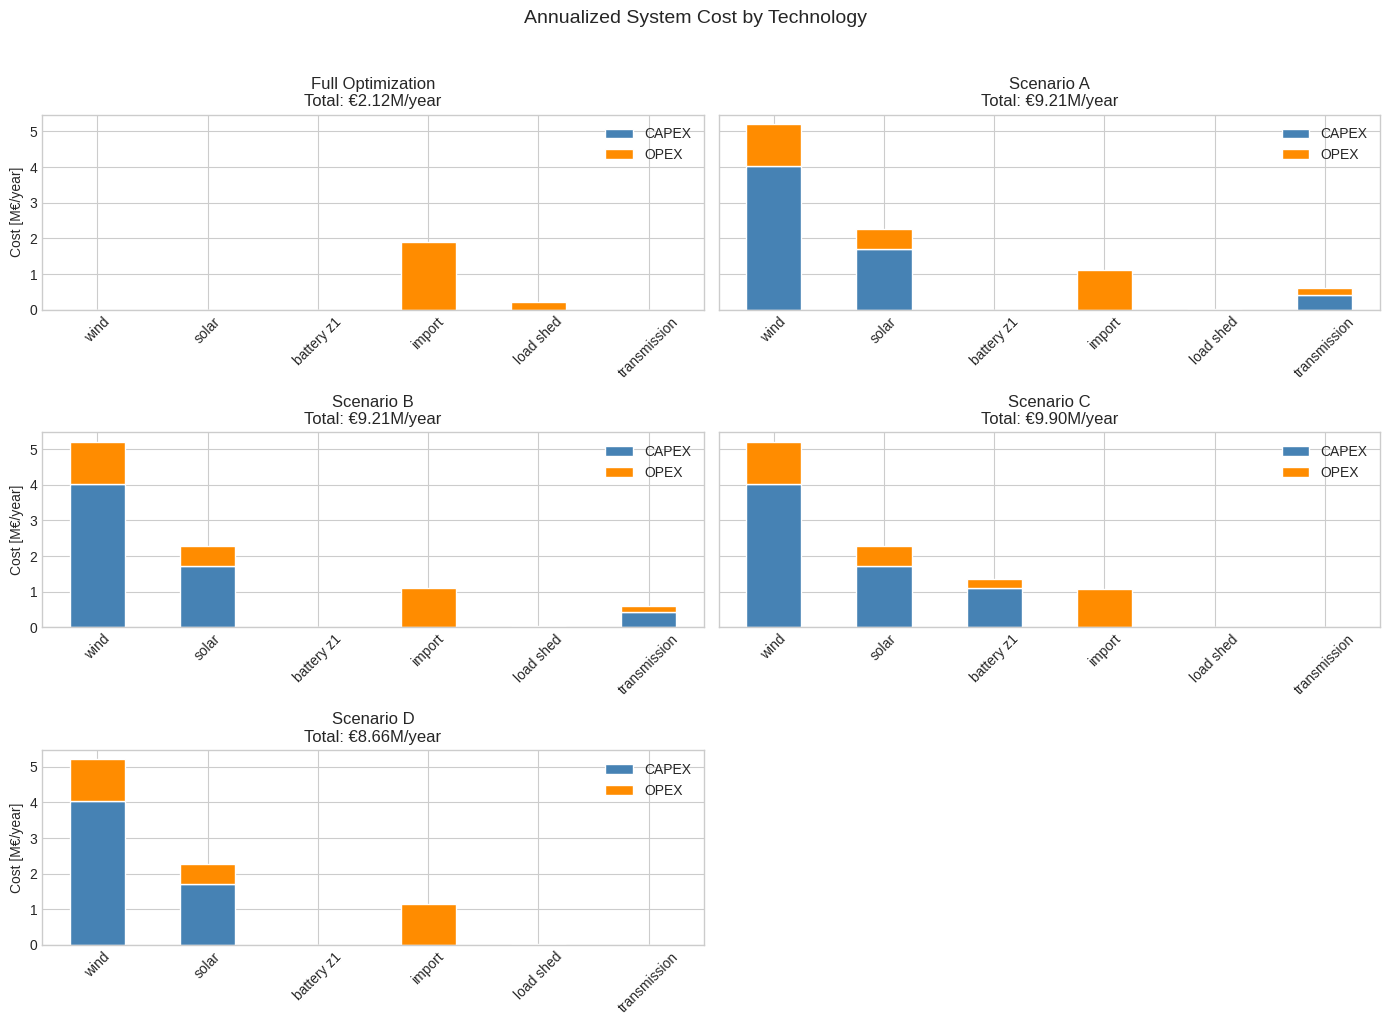

In [73]:
# ── Plot one stacked bar per scenario ─────────────────────────────────────────
# fig, axes = plt.subplots(1, len(networks), figsize=(7 * len(networks), 5), sharey=True)
#
# for ax, (label, n) in zip(axes, networks.items()):
#     cost_df = build_cost_df(n, **cost_params)
#     total   = cost_df["CAPEX"].sum() + cost_df["OPEX"].sum()
#
#     cost_df[["CAPEX", "OPEX"]].plot(kind="bar", stacked=True, ax=ax,
#                                      color=["steelblue", "darkorange"])
#     ax.set_title(f"{label}\nTotal: €{total:.2f}M/year")
#     ax.set_ylabel("Cost [M€/year]")
#     ax.tick_params(axis="x", rotation=45)
#
# plt.suptitle("Annualized System Cost by Technology", fontsize=14, y=1.02)
# plt.tight_layout()
# plt.show()

import math

n_plots = len(networks)
n_rows = 3
n_cols = math.ceil(n_plots / n_rows)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 10), sharey=True)

axes = axes.flatten()  # makes iteration easy

for ax, (label, n) in zip(axes, networks.items()):
    cost_df = build_cost_df(n, **cost_params)
    total   = cost_df["CAPEX"].sum() + cost_df["OPEX"].sum()

    cost_df[["CAPEX", "OPEX"]].plot(
        kind="bar", stacked=True, ax=ax,
        color=["steelblue", "darkorange"]
    )
    ax.set_title(f"{label}\nTotal: €{total:.2f}M/year")
    ax.set_ylabel("Cost [M€/year]")
    ax.tick_params(axis="x", rotation=45)

# hide any unused subplots
for ax in axes[len(networks):]:
    ax.set_visible(False)

plt.suptitle("Annualized System Cost by Technology", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Curtailment

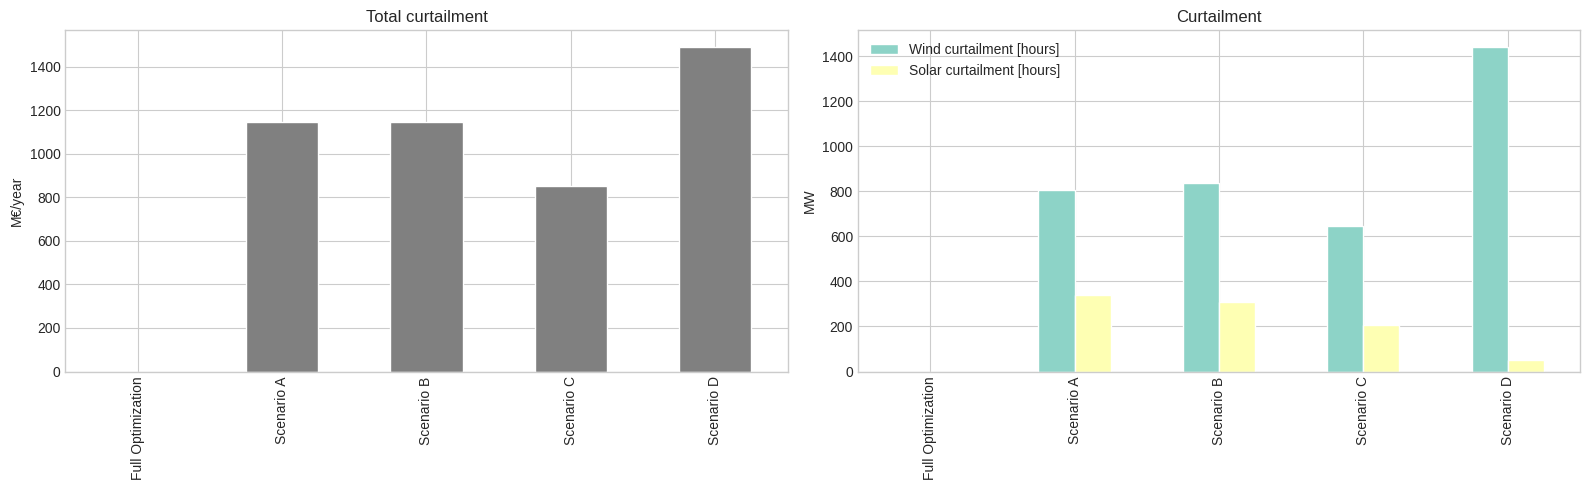

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

kpis.loc[["Total curtailment [hours]"]].T \
    .plot(kind="bar", ax=axes[0], legend=False, color="grey")
axes[0].set_title("Total curtailment"); axes[0].set_ylabel("M€/year")

kpis.loc[["Wind curtailment [hours]", "Solar curtailment [hours]"]].T \
    .plot(kind="bar", ax=axes[1]); axes[1].set_title("Curtailment"); axes[1].set_ylabel("MW")

plt.tight_layout(); plt.show()

### Transmission / Utilization of the Line

In [75]:
def plot_line_utilization(networks):
    valid = {label: n for label, n in networks.items()
             if "zone1-zone2" in n.links_t.p0.columns}

    if not valid:
        print("No networks have link flow data.")
        return

    fig, axes = plt.subplots(len(valid), 1, figsize=(12, 4 * len(valid)))
    if len(valid) == 1:
        axes = [axes]

    for ax, (label, n) in zip(axes, valid.items()):
        opt_line_capacity = n.links.p_nom_opt.get("zone1-zone2",
                            n.links.p_nom.get("zone1-zone2", 0))
        opt_flow          = n.links_t.p0["zone1-zone2"]
        utilization       = opt_flow.abs() / opt_line_capacity

        avg_util        = utilization.mean()
        max_util        = utilization.max()
        congested_hours = (utilization > 0.99).sum()

        ax.plot(utilization)
        ax.set_ylabel("Utilization [% of capacity]")
        ax.set_title(
            f"{label}  |  Capacity: {opt_line_capacity:.0f} MW  |  "
            f"Avg: {avg_util:.1%}  |  Max: {max_util:.1%}  |  Congested hrs: {congested_hours}"
        )
        ax.grid(True)

    skipped = set(networks) - set(valid)
    if skipped:
        print(f"Skipped (no link flow data): {skipped}")

    plt.suptitle("Transmission Line Utilization", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

Skipped (no link flow data): {'Full Optimization'}


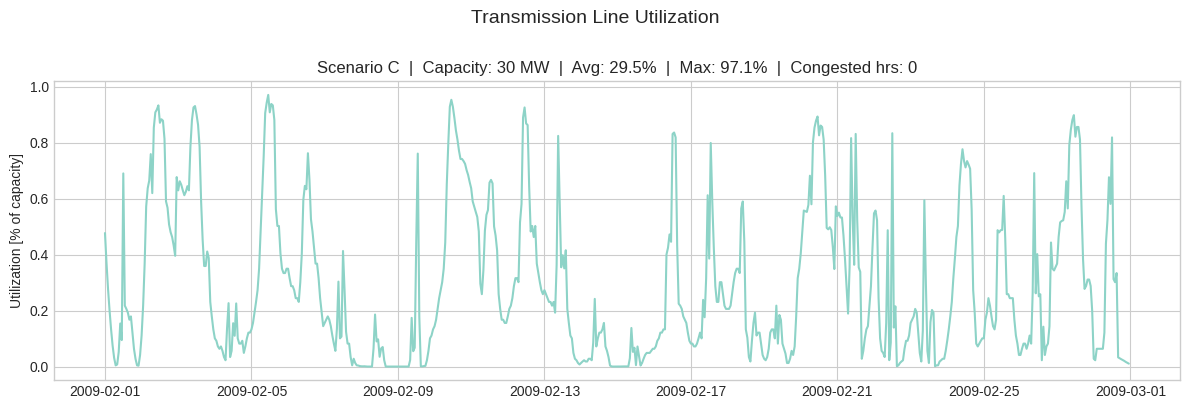

In [76]:
plot_line_utilization({"Scenario C": networks["Scenario C"],"Full Optimization": networks["Full Optimization"]})

### Unserved Demand

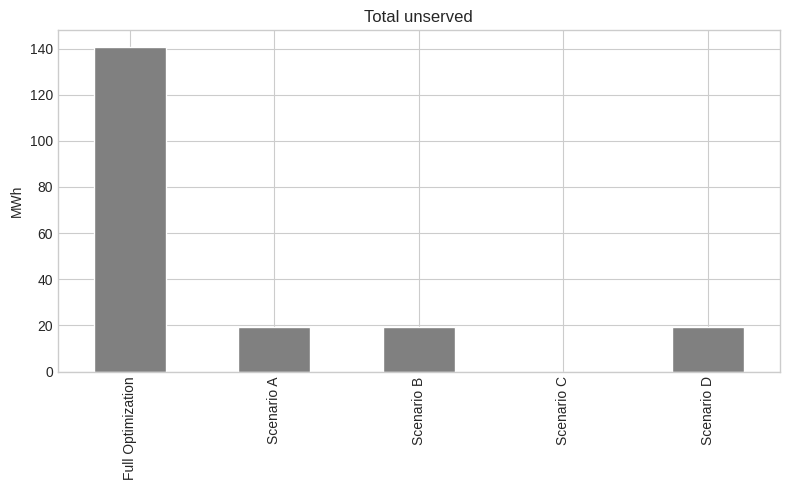

In [77]:
fig, ax = plt.subplots(figsize=(8, 5))

kpis.loc[["Total unserved [MWh]"]].T.plot(
    kind="bar",
    ax=ax,
    legend=False,
    color="grey"
)

ax.set_title("Total unserved")
ax.set_ylabel("MWh")

plt.tight_layout()
plt.show()

### Winning Scenario

(<Figure size 1643x500 with 1 Axes>,
 <Axes: xlabel='snapshot', ylabel='Energy Balance []'>,
 <seaborn.axisgrid.FacetGrid at 0x7ad8d6897610>)

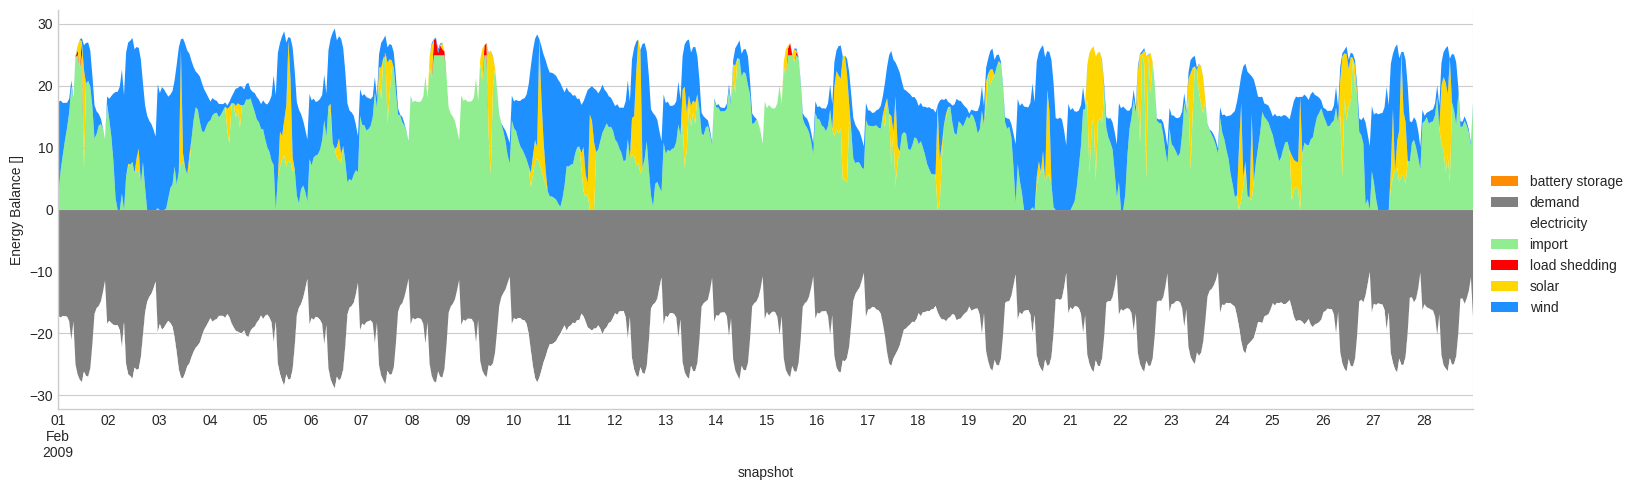

In [78]:
#energy balance
n.statistics.energy_balance.plot.area(
    bus_carrier="electricity",
    linewidth=0,
    figsize=(15, 5)
)